# Analyze the oracle comparison

Read `oracle_results_fixed_r.csv` from this notebook's directory. [02_global_oracle.ipynb](02_global_oracle.ipynb) generates this file from the activation archive.

Each row records a method's selected mask at a requested budget $R$. `gap_upper_pct` bounds the importance/latency ratio loss relative to the optimal mask with exactly $R$ rows. Paper may select fewer rows; those cases have no fixed-$R$ gap. Empty selections and zero-importance cases also have no ratio gap.

The figures use the saved importance, modeled latency and run intervals. Saturation tiles compare widths $B=\lceil\alpha s\rceil$ for $\alpha=0.25,0.5,\ldots,2$. The label `1s` means the original saturation boundary in channels, not one second. All eight variants share the same cost model.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path("oracle_results_fixed_r.csv")

In [2]:
results = pd.read_csv(RESULTS)
tile_methods = [f"Saturation tiles ({scale:g}s)" for scale in np.arange(1, 9) / 4]
missing = set(tile_methods) - set(results.method)
if missing:
    raise ValueError("Rerun 02_global_oracle.ipynb to generate the tile-width sweep; "
                     f"missing methods: {sorted(missing)}")
method_order = ["Global DP", "Paper greedy", *tile_methods, "Top-R"]
results["method"] = pd.Categorical(results.method, categories=method_order, ordered=True)
results = results.sort_values(["trace_id", "fraction", "method"])
method_colors = {"Global DP": "black", "Paper greedy": "tab:orange", "Top-R": "tab:red"}
method_colors.update(zip(tile_methods, plt.cm.viridis(np.linspace(.1, .9, len(tile_methods)))))
results.head()

,trace_id,shape,prompt,fraction,N,R_nominal,R_selected,fill_pct,method,status,...,chunks,short_chunks,shortfall_rows,overhead_ms,gap_lower_pct,gap_upper_pct,oracle_calls,intervals,tile_scale,tile_width
0,0,896x896,0,0.1,896,89,89,100.000000,Global DP,ok,...,1,1,29.285714,0.003020,0.000000,0.000091,21,"[[483, 572]]",NaN,NaN
1,0,896x896,0,0.1,896,89,88,98.876404,Paper greedy,ok,...,1,1,30.285714,0.003123,NaN,NaN,21,"[[480, 568]]",NaN,NaN
2,0,896x896,0,0.1,896,89,89,100.000000,Saturation tiles (0.25s),ok,...,3,3,265.857143,0.027412,30.551544,30.551607,21,"[[30, 60], [480, 510], [531, 560]]",0.25,30.0
3,0,896x896,0,0.1,896,89,89,100.000000,Saturation tiles (0.5s),ok,...,2,2,147.571429,0.015216,10.608068,10.608149,21,"[[48, 77], [480, 540]]",0.50,60.0
4,0,896x896,0,0.1,896,89,89,100.000000,Saturation tiles (0.75s),ok,...,1,1,29.285714,0.003020,6.097559,6.097645,21,"[[0, 89]]",0.75,89.0


## 1. Compare ratio gaps and fragmentation

In [3]:
frame = results[results.status == "ok"]
eligible = frame[(frame.R_selected == frame.R_nominal) & frame.gap_upper_pct.notna()]

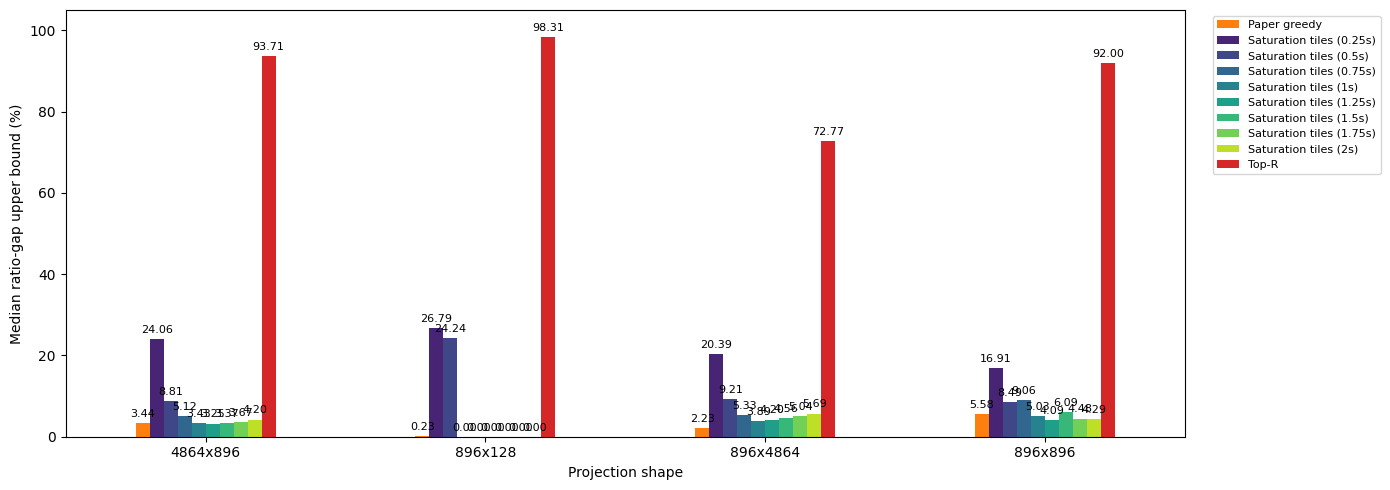

In [4]:
gaps = eligible[eligible.method != "Global DP"].groupby(["shape", "method"], observed=True).gap_upper_pct.median().unstack()
gaps = gaps.reindex(columns=[name for name in method_order if name != "Global DP"])
ax = gaps.plot.bar(figsize=(14, 5), rot=0, color=[method_colors[name] for name in gaps.columns])
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
plt.ylim(0, 105)
plt.xlabel("Projection shape")
plt.ylabel("Median ratio-gap upper bound (%)")
plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Figure 1.** Median ratio-gap upper bounds by shape. The table gives case counts, minimum fill percentage, median gap, run count and short-run overhead. Paper's gap uses only exact-fill cases with a defined ratio, so its bars and the other methods' bars may describe different subsets. Missing gaps have no eligible cases.

The short-run deficit is $D(M)=\sum_C(s-|C|)_+$, where $s$ is the fitted boundary in rows. With short and long slopes $b_1,b_2$, the saved overhead is $(b_2-b_1)D(M)$ and total cost is $L=b_2|M|+(b_2-b_1)D(M)$.

In [5]:
summary = results.groupby(["shape", "method"], observed=True).agg(
    cases=("method", "size"), gap_cases=("gap_upper_pct", "count"),
    min_fill_pct=("fill_pct", "min"), median_gap_pct=("gap_upper_pct", "median"),
    median_runs=("chunks", "median"), median_overhead_ms=("overhead_ms", "median"))
summary.round(3)

cases  gap_cases  min_fill_pct  \
shape    method                                                     
4864x896 Global DP                   288        288       100.000   
         Paper greedy                288         64        99.918   
         Saturation tiles (0.25s)    288        288       100.000   
         Saturation tiles (0.5s)     288        288       100.000   
         Saturation tiles (0.75s)    288        288       100.000   
         Saturation tiles (1s)       288        288       100.000   
         Saturation tiles (1.25s)    288        288       100.000   
         Saturation tiles (1.5s)     288        288       100.000   
         Saturation tiles (1.75s)    288        288       100.000   
         Saturation tiles (2s)       288        288       100.000   
         Top-R                       288        288       100.000   
896x128  Global DP                   288        288       100.000   
         Paper greedy                288         32        71.910   
         Saturation tiles (0.25s)    288        288       100.000   
         Saturation tiles (0.5s)     288        288       100.000   
         Saturation tiles (0.75s)    288        288       100.000   
         Saturation tiles (1s)       288        288       100.000   
         Saturation tiles (1.25s)    288        288       100.000   
         Saturation tiles (1.5s)     288        288       100.000   
         Saturation tiles (1.75s)    288        288       100.000   
         Saturation tiles (2s)       288        288       100.000   
         Top-R                       288        288       100.000   
896x4864 Global DP                   288        288       100.000   
         Paper greedy                288        288       100.000   
         Saturation tiles (0.25s)    288        288       100.000   
         Saturation tiles (0.5s)     288        288       100.000   
         Saturation tiles (0.75s)    288        288       100.000   
         Saturation tiles (1s)       288        288       100.000   
         Saturation tiles (1.25s)    288        288       100.000   
         Saturation tiles (1.5s)     288        288       100.000   
         Saturation tiles (1.75s)    288        288       100.000   
         Saturation tiles (2s)       288        288       100.000   
         Top-R                       288        288       100.000   
896x896  Global DP                   288        288       100.000   
         Paper greedy                288         96        98.324   
         Saturation tiles (0.25s)    288        288       100.000   
         Saturation tiles (0.5s)     288        288       100.000   
         Saturation tiles (0.75s)    288        288       100.000   
         Saturation tiles (1s)       288        288       100.000   
         Saturation tiles (1.25s)    288        288       100.000   
         Saturation tiles (1.5s)     288        288       100.000   
         Saturation tiles (1.75s)    288        288       100.000   
         Saturation tiles (2s)       288        288       100.000   
         Top-R                       288        288       100.000   

                                   median_gap_pct  median_runs  \
shape    method                                                  
4864x896 Global DP                          0.000         18.0   
         Paper greedy                       3.443         20.0   
         Saturation tiles (0.25s)          24.064         32.0   
         Saturation tiles (0.5s)            8.814         16.0   
         Saturation tiles (0.75s)           5.123         11.0   
         Saturation tiles (1s)              3.427          9.0   
         Saturation tiles (1.25s)           3.248          7.0   
         Saturation tiles (1.5s)            3.365          7.0   
         Saturation tiles (1.75s)           3.667          6.0   
         Saturation tiles (2s)              4.201          5.0   
         Top-R                             93.713       1018.5   
89

## 2. Inspect importance–latency trajectories

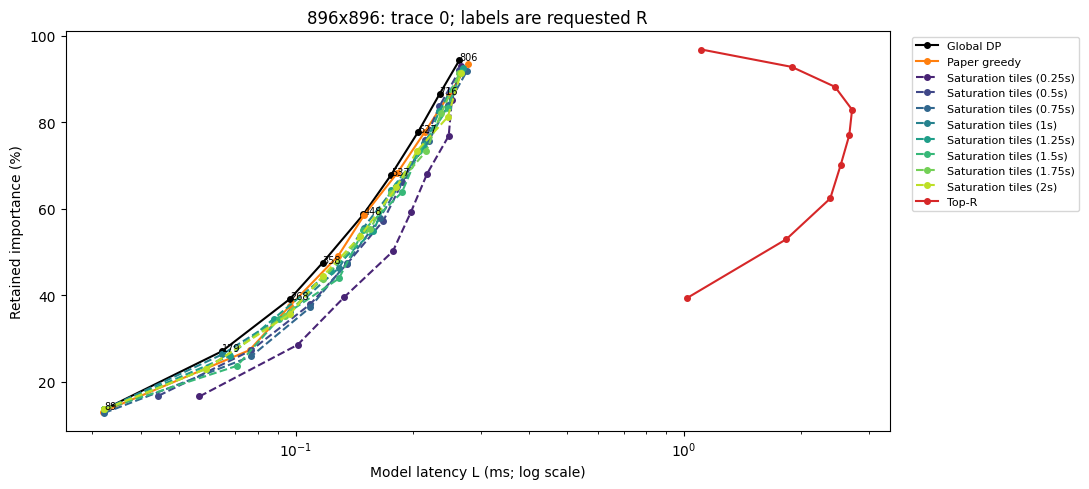

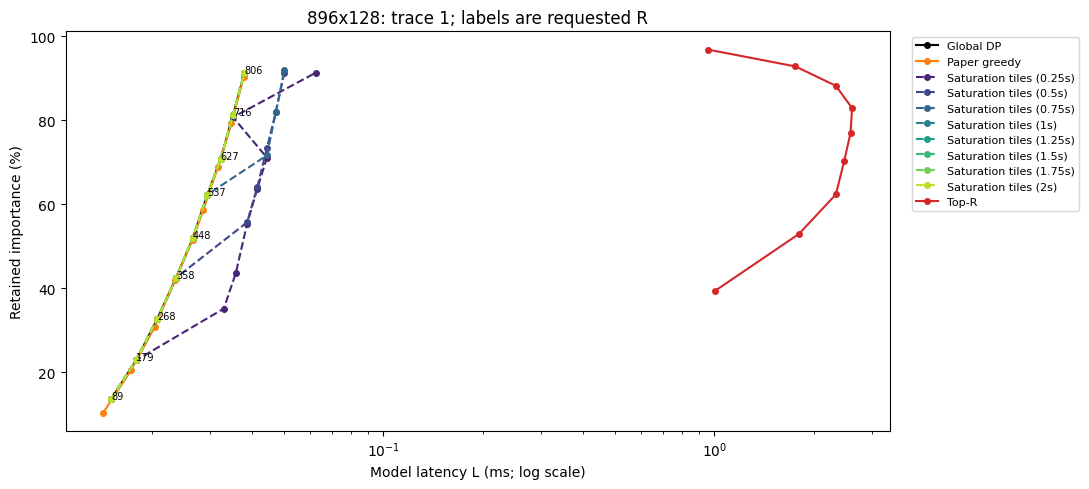

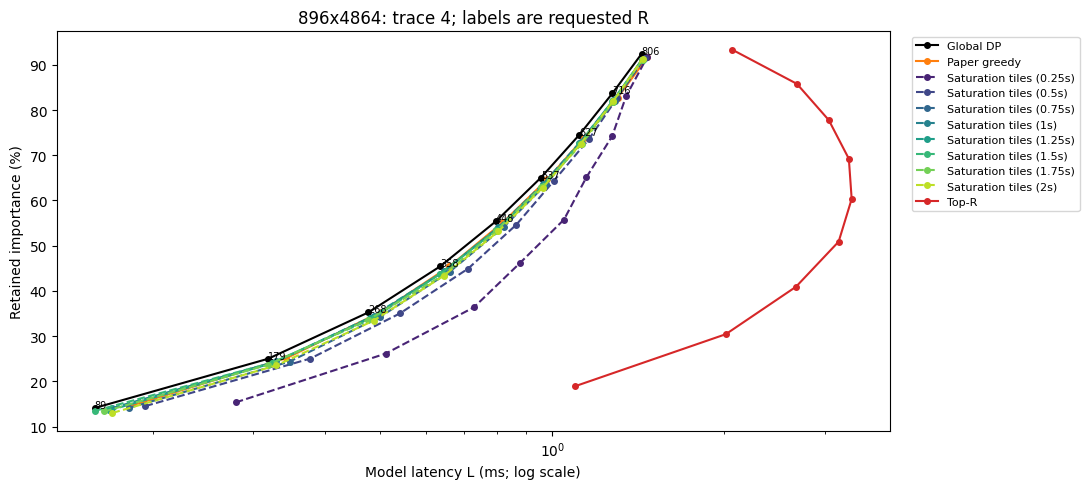

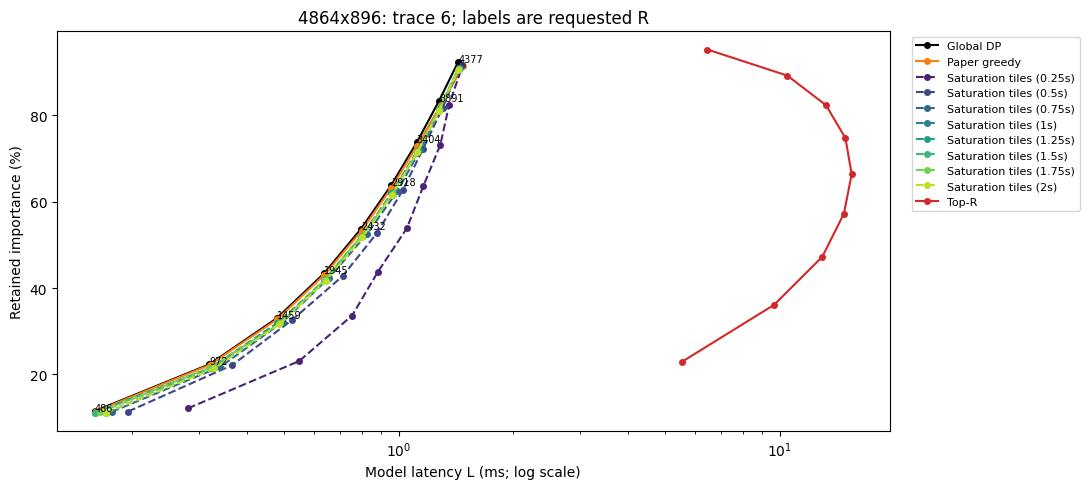

In [6]:
for shape, data in frame.groupby("shape", sort=False):
    points = data[data.trace_id == data.trace_id.min()]
    plt.figure(figsize=(11, 5))
    for name, group in points.groupby("method", sort=False, observed=True):
        group = group.sort_values("fraction")
        plt.plot(group.latency, group.retained_pct, "o", label=name, ms=4,
                 color=method_colors[name], linestyle="--" if name in tile_methods else "-")
        if name == "Global DP":
            for row in group.itertuples():
                plt.annotate(str(row.R_nominal), (row.latency, row.retained_pct), fontsize=7)
    plt.xscale("log")
    plt.xlabel("Model latency L (ms; log scale)")
    plt.ylabel("Retained importance (%)")
    plt.title(f"{shape}: trace {points.trace_id.iloc[0]}; labels are requested R")
    plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

**Figure 2.** Importance–latency trajectories for the first available trace of each shape. Points are masks; lines connect requested budgets, and oracle labels give $R$. Paper may underfill. Latency can decrease as intervals merge and their short-run penalty falls. Empty and zero-importance cases are omitted. Fixed-$R$ ratio optima need not form the complete Pareto frontier.

## 3. Inspect selected runs

In [7]:
def saved_mask(row):
    mask = np.zeros(int(row.N), bool)
    for start, end in json.loads(row.intervals):
        mask[start:end] = True
    return mask


first = results[results.trace_id == results.trace_id.min()]
fraction = first.fraction.iloc[(first.fraction - .5).abs().argmin()]
example = first[np.isclose(first.fraction, fraction)].set_index("method")
methods = {name: saved_mask(row) for name, row in example.iterrows()}

In [8]:
example[["R_nominal", "R_selected", "importance", "latency",
         "chunks", "gap_upper_pct"]].round(3)

,R_nominal,R_selected,importance,latency,chunks,gap_upper_pct
method,,,,,,
Global DP,448,448,525.575,0.149,4,0.000
Paper greedy,448,448,525.090,0.150,4,0.709
Saturation tiles (0.25s),448,448,530.751,0.198,8,23.834
Saturation tiles (0.5s),448,448,512.152,0.168,5,13.369
Saturation tiles (0.75s),448,448,517.857,0.165,4,10.595
Saturation tiles (1s),448,448,498.319,0.150,4,5.279
Saturation tiles (1.25s),448,448,491.212,0.159,4,11.911
Saturation tiles (1.5s),448,448,492.478,0.150,2,6.325
Saturation tiles (1.75s),448,448,495.558,0.156,2,9.364


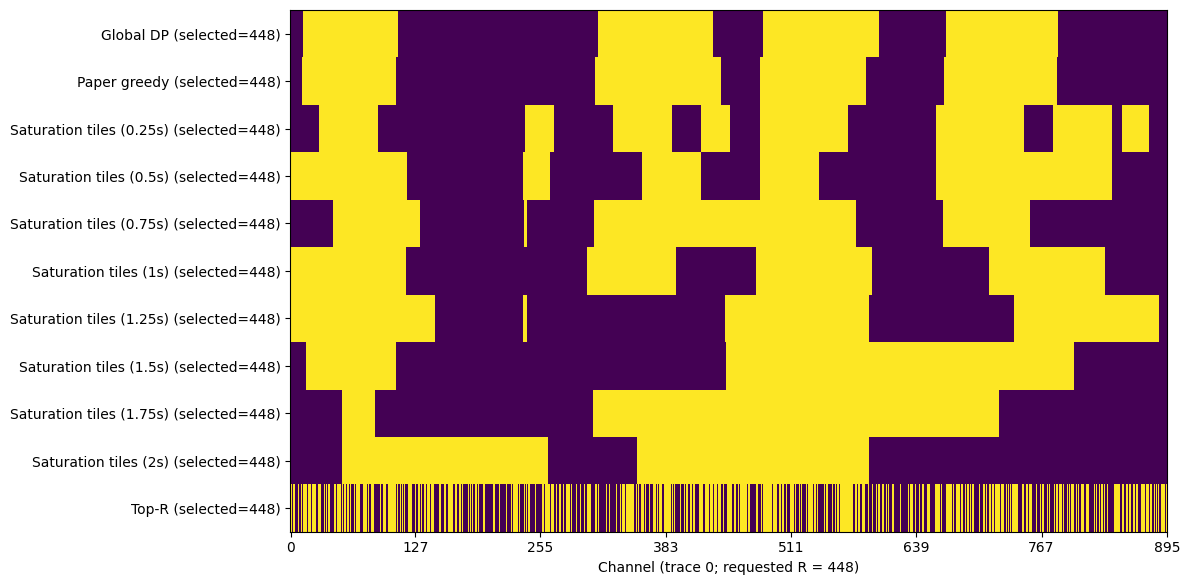

In [9]:
N, R = int(example.N.iloc[0]), int(example.R_nominal.iloc[0])
plt.figure(figsize=(12, max(2.4, 0.45 * len(methods) + 1)))
plt.imshow(np.array(list(methods.values())), aspect="auto", interpolation="nearest")
plt.yticks(range(len(methods)), [f"{name} (selected={mask.sum()})" for name, mask in methods.items()])
plt.xticks(np.linspace(0, N - 1, 8, dtype=int))
plt.xlabel(f"Channel (trace {int(example.trace_id.iloc[0])}; requested R = {R})")
plt.tight_layout()
plt.show()

**Figure 3.** Bright cells are selected channels. The example uses the first available trace and its available budget closest to one half. The table gives importance and cost; the image shows how selection is distributed across runs. Short runs incur the deficit penalty above, but a valuable short run can still improve the ratio.

## 4. Summarize the comparison

The tables below summarize gaps over all eligible cases and then compare Paper and all eight tile widths on the same cases, matched by trace, shape and requested budget. Medians weight each case equally. A missing median means that no eligible cases exist.

In [10]:
gap_table = eligible.pivot(index=["trace_id", "shape", "R_nominal", "fraction"],
                           columns="method", values="gap_upper_pct").reindex(columns=results.method.unique())
paired = gap_table.reindex(columns=["Paper greedy", *tile_methods]).dropna()
pd.concat({"All eligible cases": gap_table.agg(["median", "count"]).T,
           "Matched Paper / tiles": paired.agg(["median", "count"]).T},
          names=["Comparison", "Method"]).rename(
              columns={"median": "Median gap upper bound (%)", "count": "Cases"}).round(3)

Median gap upper bound (%)  \
Comparison            Method                                                 
All eligible cases    Global DP                                      0.000   
                      Paper greedy                                   2.417   
                      Saturation tiles (0.25s)                      23.918   
                      Saturation tiles (0.5s)                        8.967   
                      Saturation tiles (0.75s)                       5.719   
                      Saturation tiles (1s)                          3.088   
                      Saturation tiles (1.25s)                       3.020   
                      Saturation tiles (1.5s)                        3.291   
                      Saturation tiles (1.75s)                       3.252   
                      Saturation tiles (2s)                          3.394   
                      Top-R                                         92.590   
Matched Paper / tiles Paper greedy                                   2.417   
                      Saturation tiles (0.25s)                      25.075   
                      Saturation tiles (0.5s)                       12.064   
                      Saturation tiles (0.75s)                       6.745   
                      Saturation tiles (1s)                          4.584   
                      Saturation tiles (1.25s)                       4.157   
                      Saturation tiles (1.5s)                        4.554   
                      Saturation tiles (1.75s)                       5.057   
                      Saturation tiles (2s)                          6.621   

                                                 Cases  
Comparison            Method                            
All eligible cases    Global DP                 1152.0  
                      Paper greedy               480.0  
                      Saturation tiles (0.25s)  1152.0  
                      Saturation tiles (0.5s)   1152.0  
                      Saturation tiles (0.75s)  1152.0  
                      Saturation tiles (1s)     1152.0  
                      Saturation tiles (1.25s)  1152.0  
                      Saturation tiles (1.5s)   1152.0  
                      Saturation tiles (1.75s)  1152.0  
                      Saturation tiles (2s)     1152.0  
                      Top-R                     1152.0  
Matched Paper / tiles Paper greedy               480.0  
                      Saturation tiles (0.25s)   480.0  
                      Saturation tiles (0.5s)    480.0  
                      Saturation tiles (0.75s)   480.0  
                      Saturation tiles (1s)      480.0  
                      Saturation tiles (1.25s)   480.0  
                      Saturation tiles (1.5s)    480.0  
                      Saturation tiles (1.75s)   480.0  
                      Saturation tiles (2s)      480.0

The oracle searches the full fixed-$R$ mask space to the specified ratio tolerance. Its gaps quantify how much ratio each heuristic leaves under the fitted cost. The decomposition $L=b_2|M|+(b_2-b_1)D(M)$ connects that comparison to run geometry: at equal row count, differences in modeled latency come entirely from short-run deficit.

The conclusions concern activation-magnitude importance and an additive latency model. They do not establish end-to-end accuracy or measured SSD speedup; native task splitting and scheduling are outside this model.